<a href="https://www.kaggle.com/code/mh0386/motorcycle-data-analysis?scriptVersionId=129439270" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter, dataset_load

# Read Data

In [ ]:
data = dataset_load(KaggleDatasetAdapter.PANDAS, "nehalbirla/motorcycle-dataset", "BIKE DETAILS.csv")

In [ ]:
data

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [ ]:
data.shape

(1061, 7)

In [ ]:
data.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='str')

# Null Values

In [ ]:
data.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [ ]:
data.dtypes

name                     str
selling_price          int64
year                   int64
seller_type              str
owner                    str
km_driven              int64
ex_showroom_price    float64
dtype: object

# Statistical Analysis 

In [ ]:
data.describe().round(2)

,selling_price,year,km_driven,ex_showroom_price
count,1061.00,1061.00,1061.00,626.00
mean,59638.15,2013.87,34359.83,87958.71
std,56304.29,4.30,51623.15,77496.59
min,5000.00,1988.00,350.00,30490.00
25%,28000.00,2011.00,13500.00,54852.00
50%,45000.00,2015.00,25000.00,72752.50
75%,70000.00,2017.00,43000.00,87031.50
max,760000.00,2020.00,880000.00,1278000.00


# First 10 unique values from each Column

In [ ]:
for col in data.columns:
    print(col, "column")
    print(f"First 5 unique values:\n{data[col].unique()[:5]}")
    print(f"Number of unique values: {data[col].nunique()}\n")

name column
First 5 unique values:
<StringArray>
[          'Royal Enfield Classic 350',                           'Honda Dio',
 'Royal Enfield Classic Gunmetal Grey',   'Yamaha Fazer FI V 2.0 [2016-2018]',
               'Yamaha SZ [2013-2014]']
Length: 5, dtype: str
Number of unique values: 279

selling_price column
First 5 unique values:
[175000  45000 150000  65000  20000]
Number of unique values: 130

year column
First 5 unique values:
[2019 2017 2018 2015 2011]
Number of unique values: 28

seller_type column
First 5 unique values:
<StringArray>
['Individual', 'Dealer']
Length: 2, dtype: str
Number of unique values: 2

owner column
First 5 unique values:
<StringArray>
['1st owner', '2nd owner', '3rd owner', '4th owner']
Length: 4, dtype: str
Number of unique values: 4

km_driven column
First 5 unique values:
[  350  5650 12000 23000 21000]
Number of unique values: 304

ex_showroom_price column
First 5 unique values:
[    nan 148114.  89643.  53857.  87719.]
Number of unique values

# Visualize Columns Data

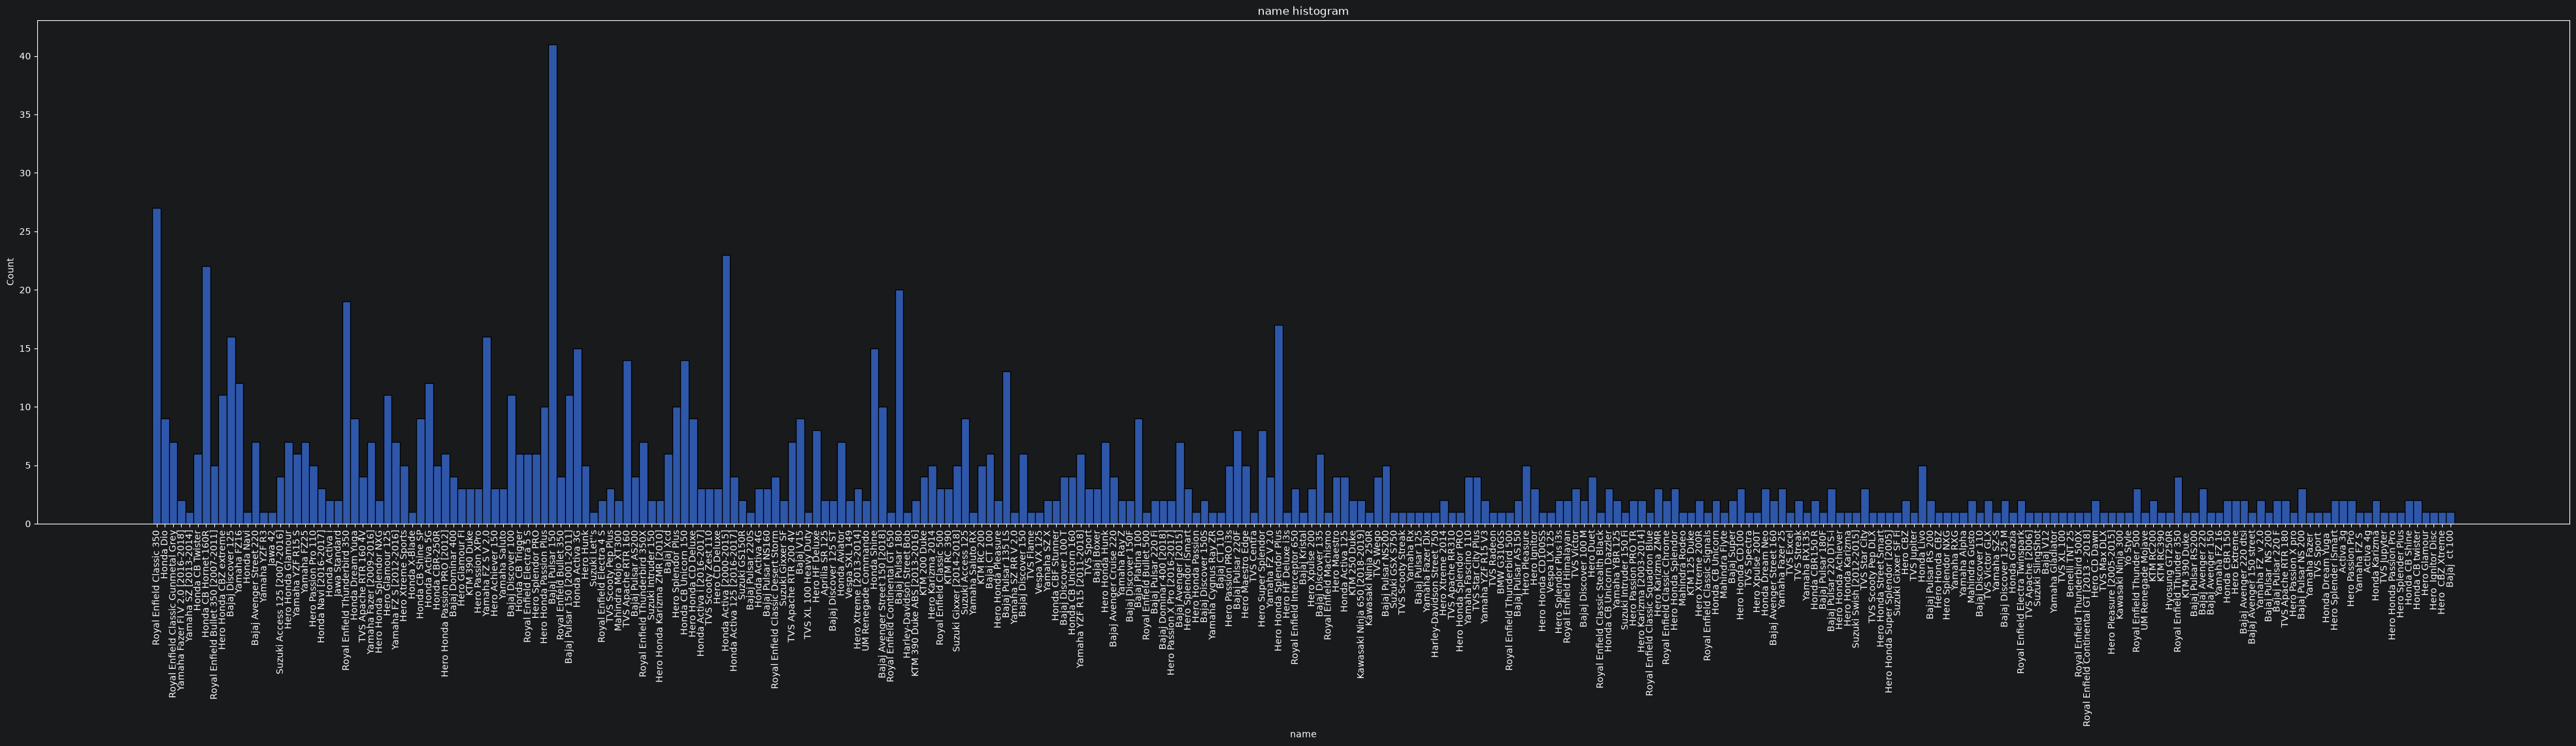

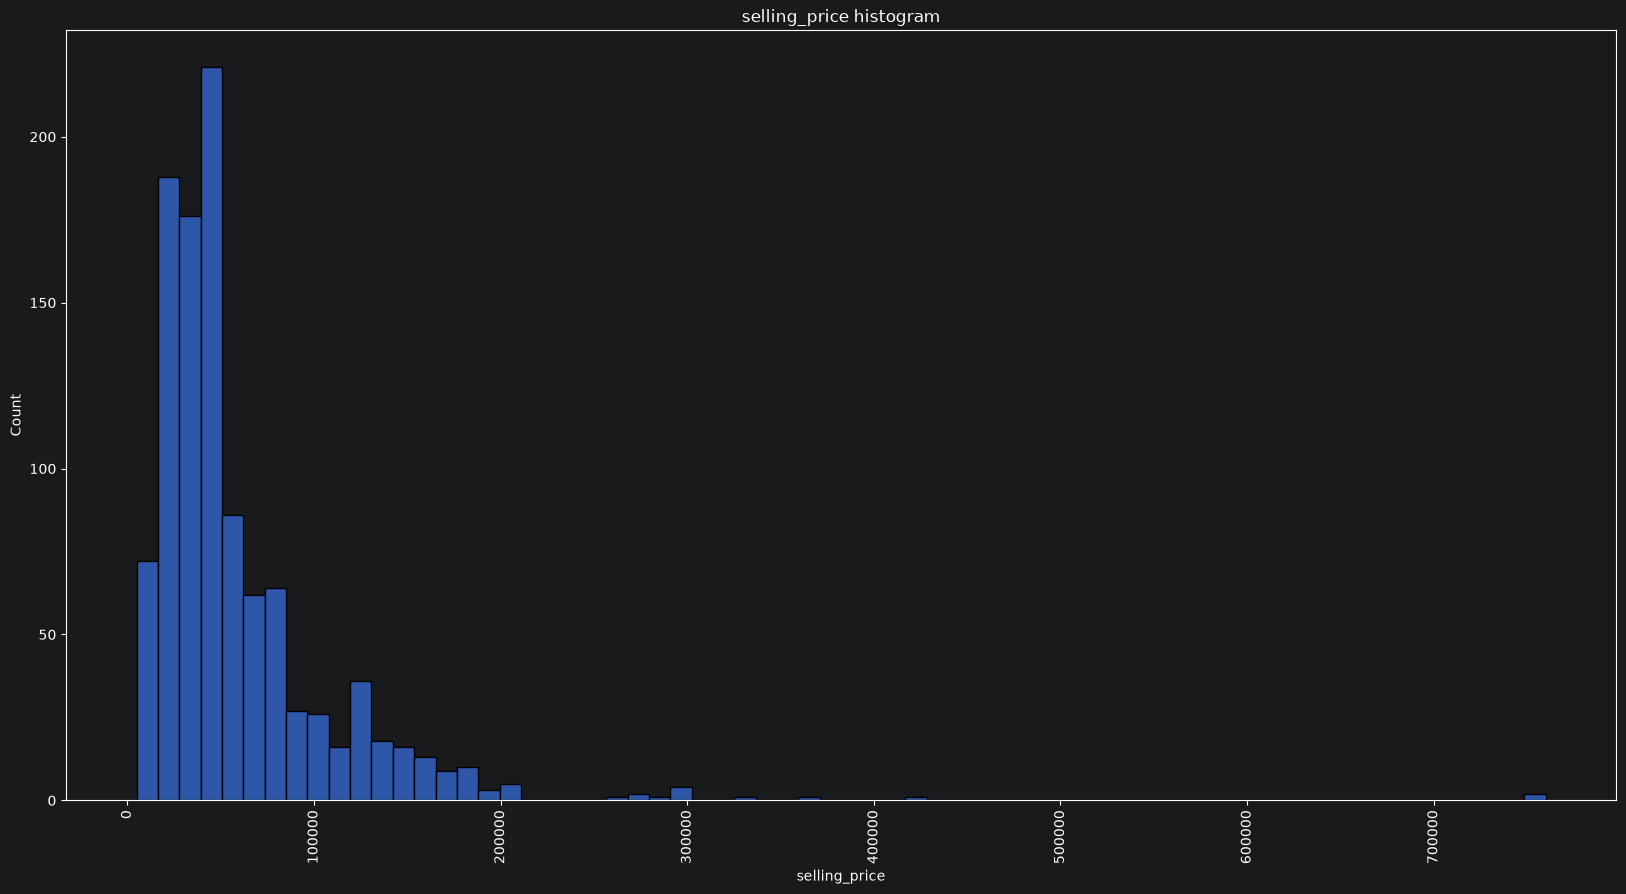

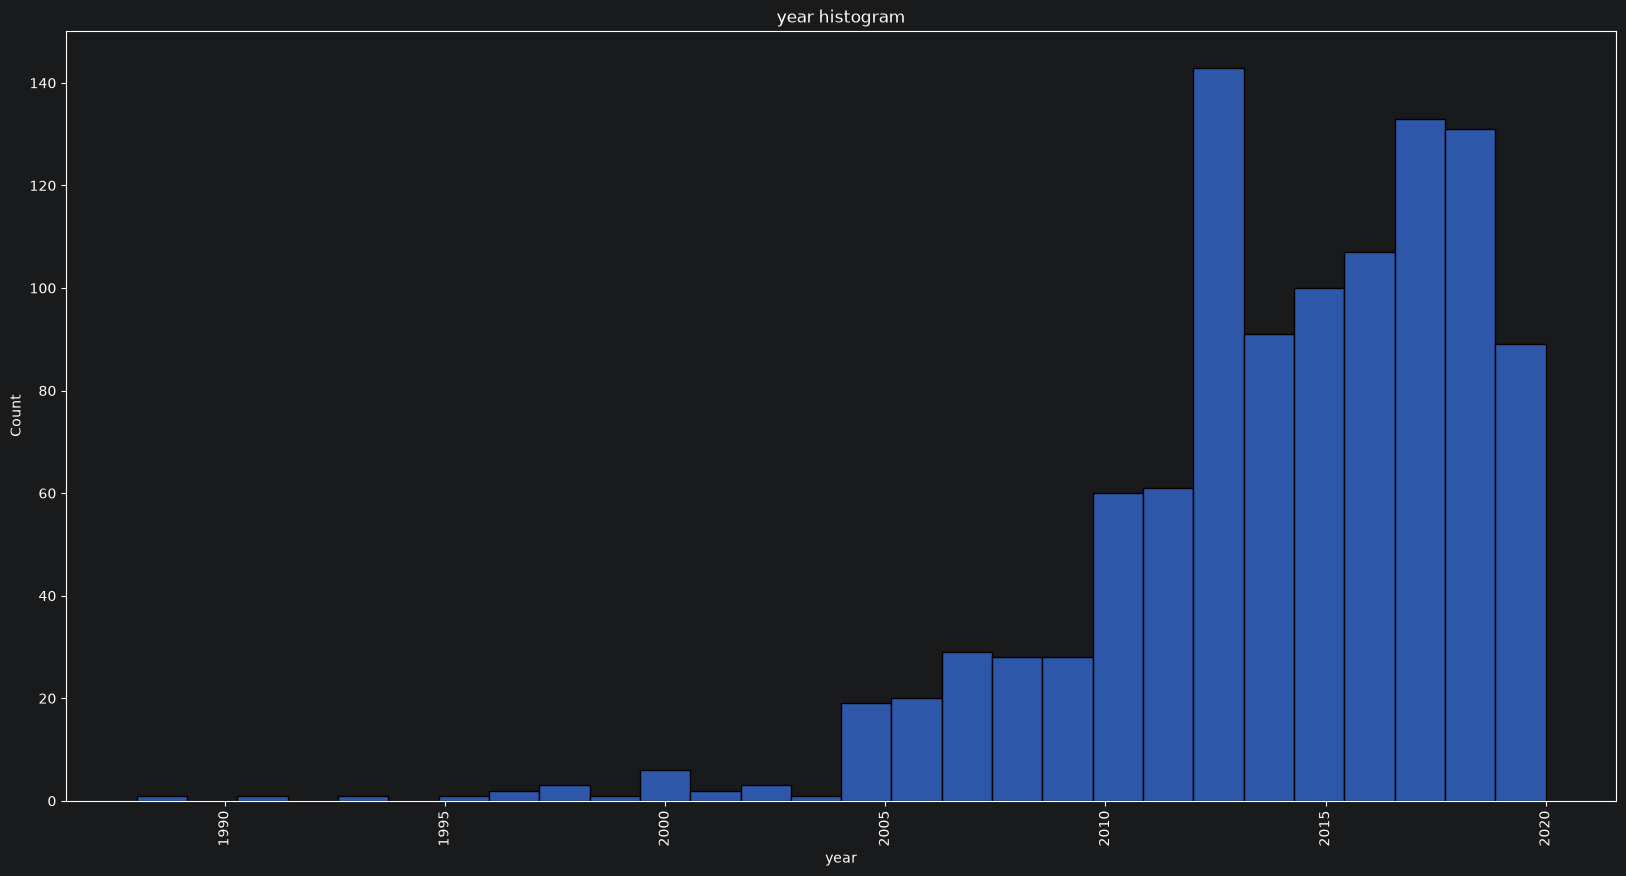

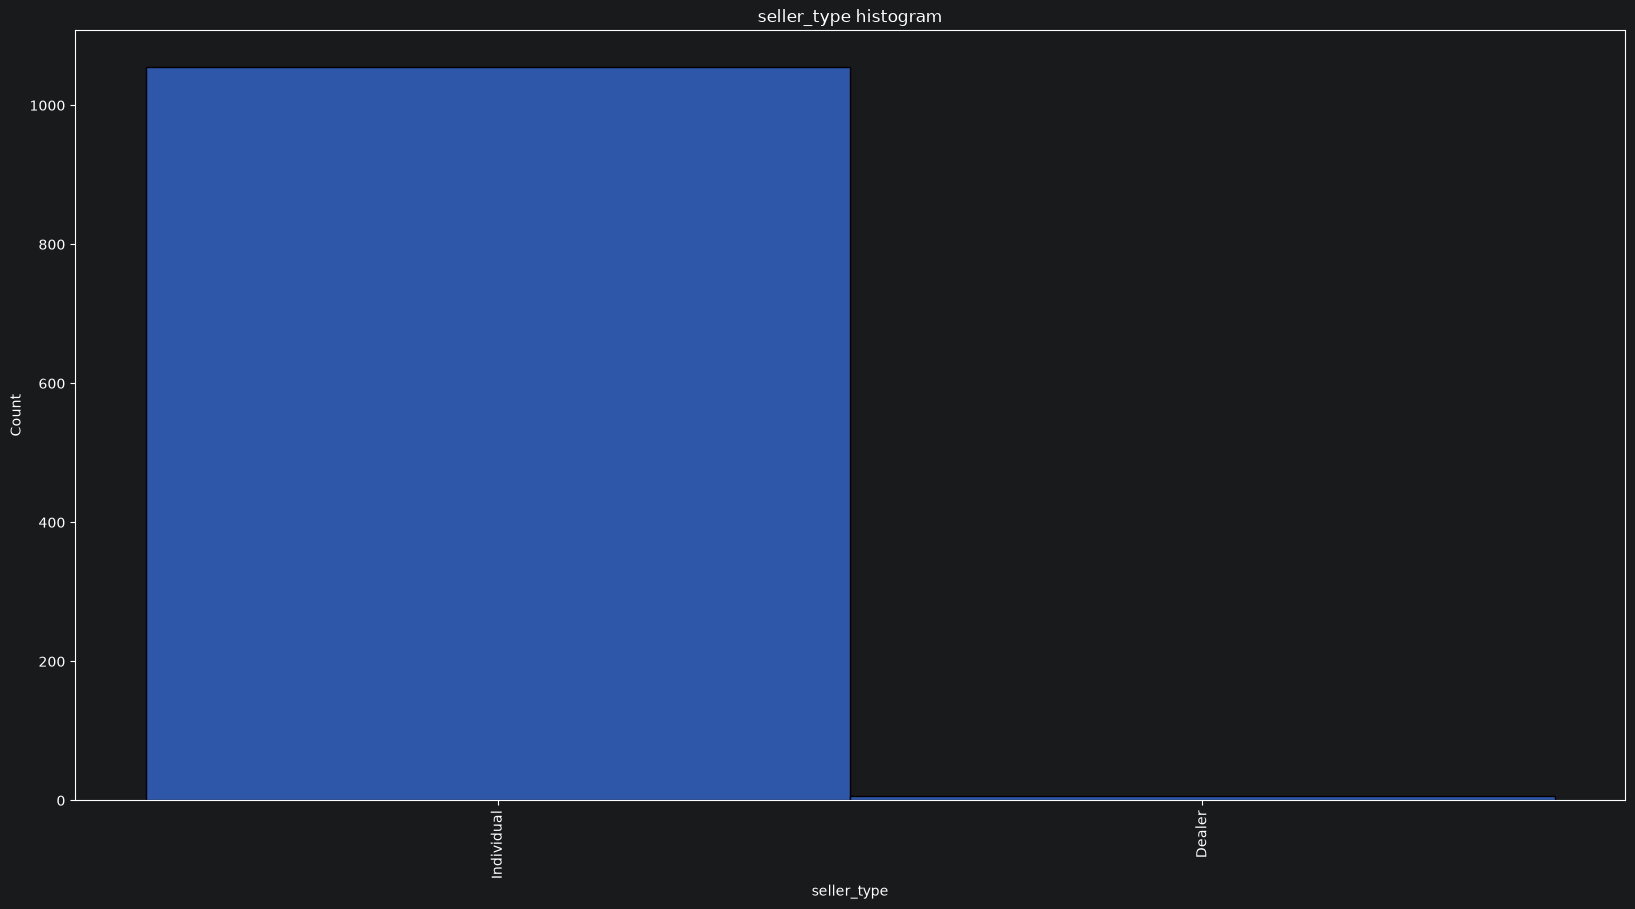

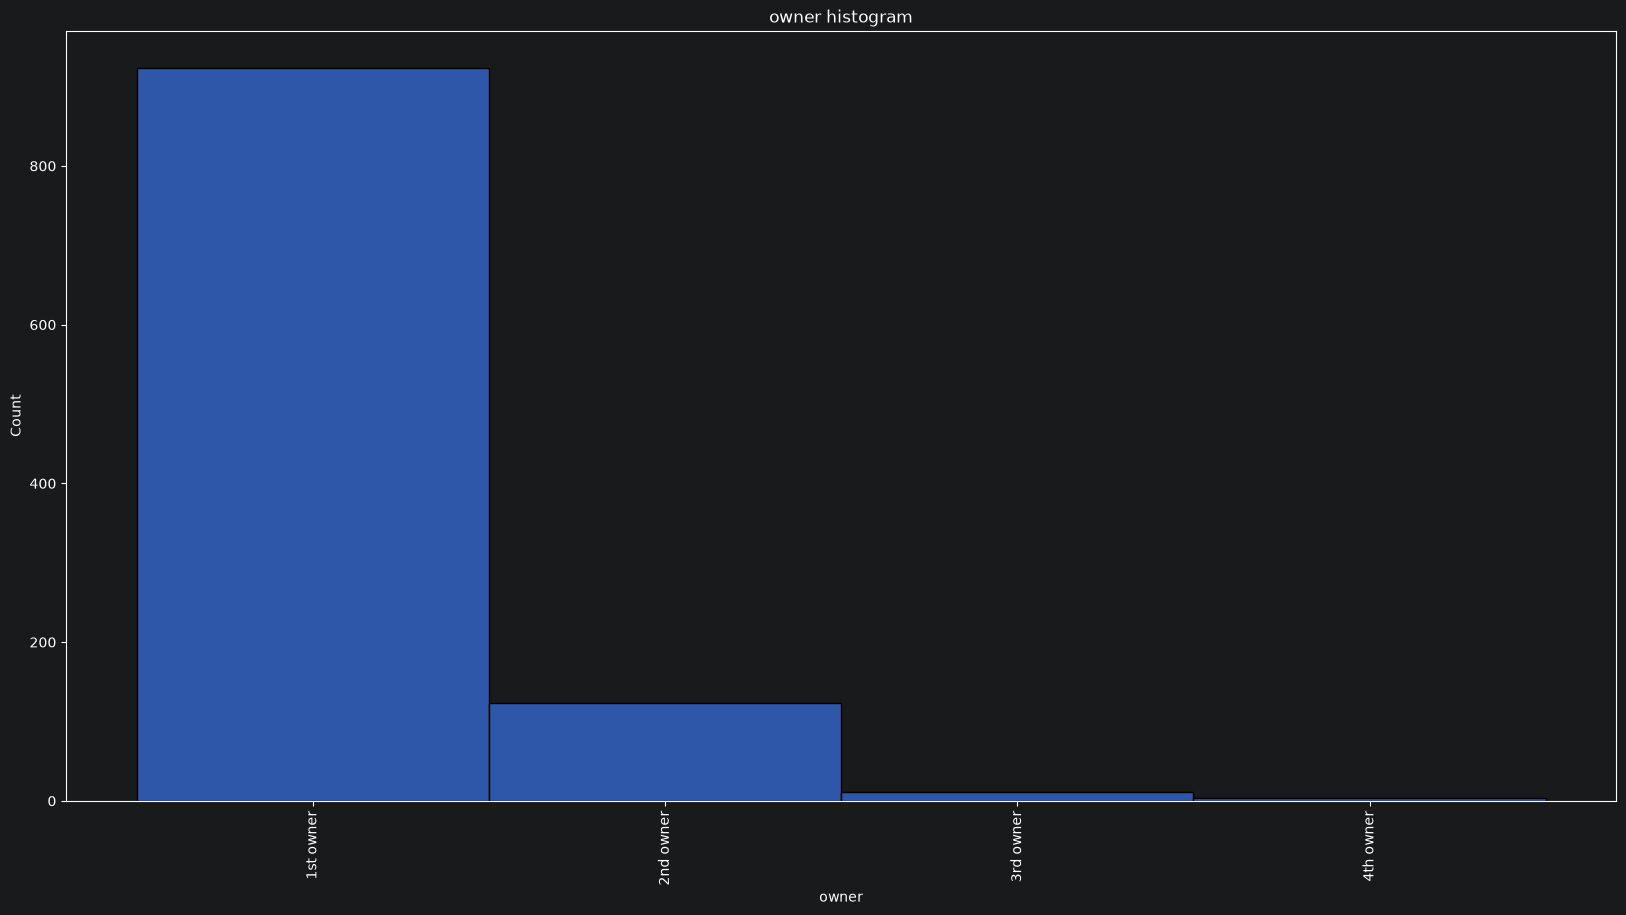

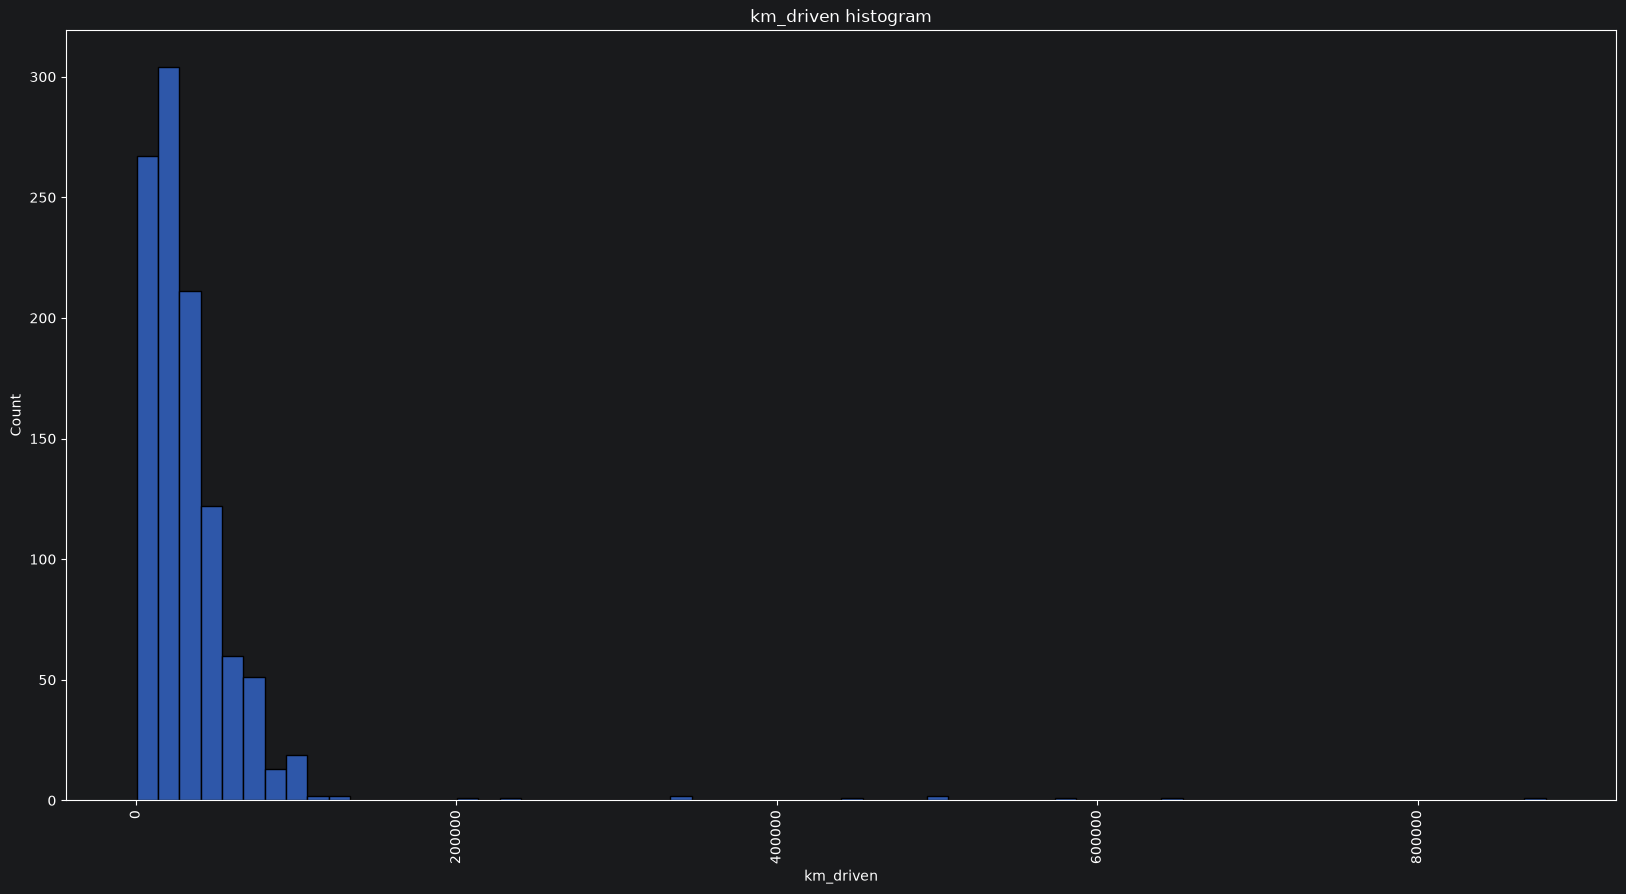

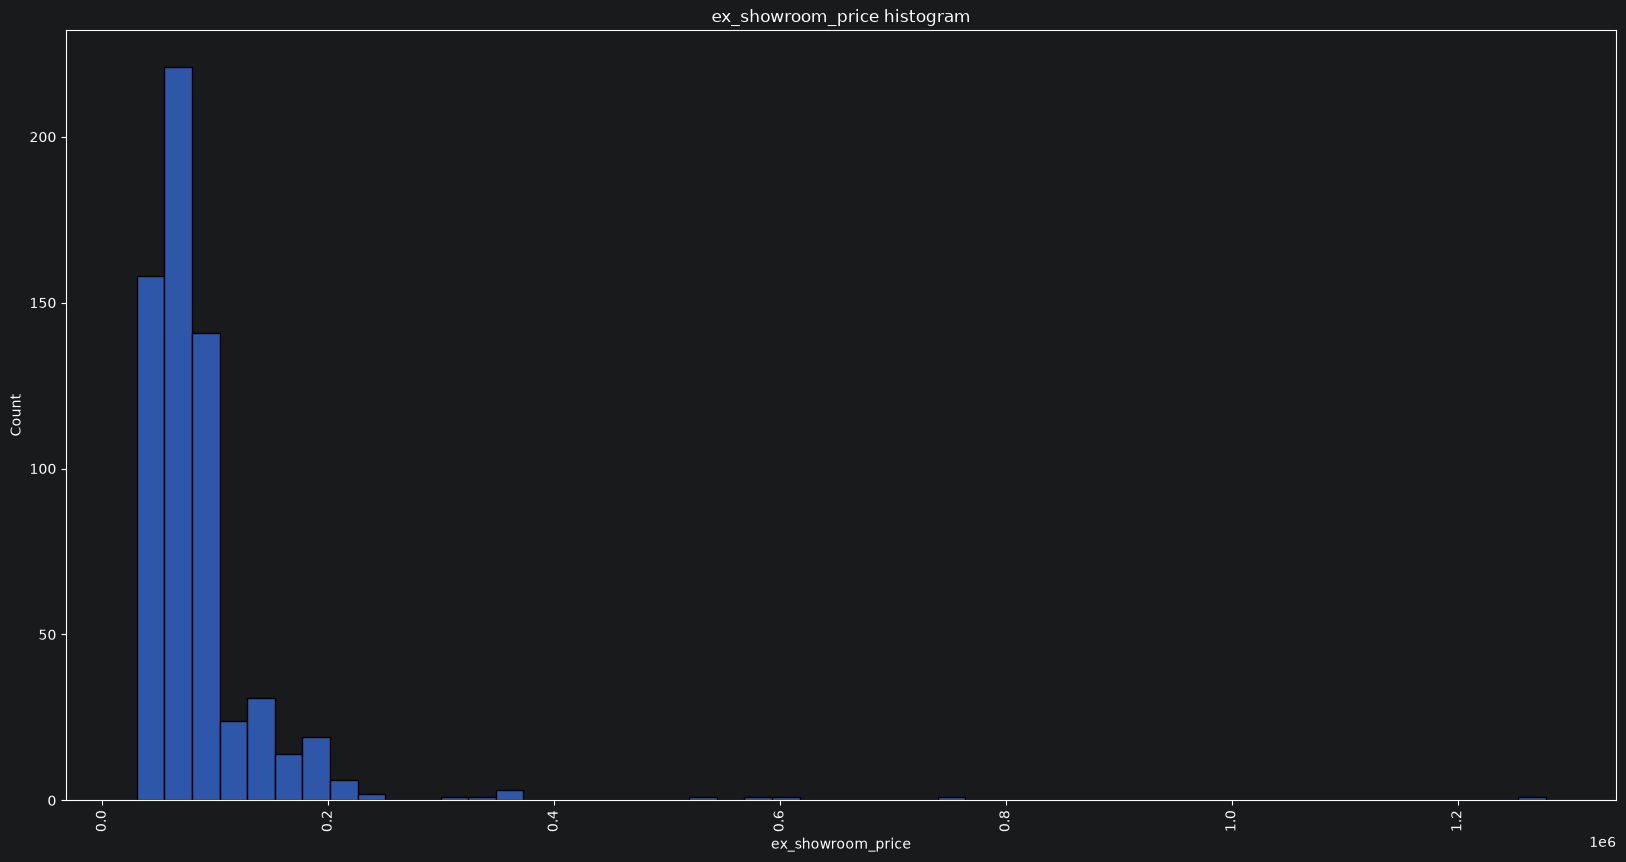

In [ ]:
for col in data.columns:
    if col == "name":
        fig, ax = plt.subplots(figsize=(50, 10))
    else:
        fig, ax = plt.subplots(figsize=(20, 10))
    ax.tick_params(axis="x", rotation=90)
    plt.title(f"{col} histogram")
    sns.histplot(data=data, x=col, ax=ax)
    plt.show()

# Data Cleaning 

In [ ]:
data.ex_showroom_price.fillna(data.ex_showroom_price.mean(), inplace=True)

C:\Users\mohamed\AppData\Local\Temp\ipykernel_26132\1653153897.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data.ex_showroom_price.fillna(data.ex_showroom_price.mean(), inplace=True)


0        87958.714058
1        87958.714058
2       148114.000000
3        89643.000000
4        87958.714058
            ...      
1056     52000.000000
1057     51000.000000
1058     57000.000000
1059     58000.000000
1060     75000.000000
Name: ex_showroom_price, Length: 1061, dtype: float64

# Null Values after Data Cleaning 

In [ ]:
data.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

# Visualize the "ex_showroom_price" Column after Data Cleaning

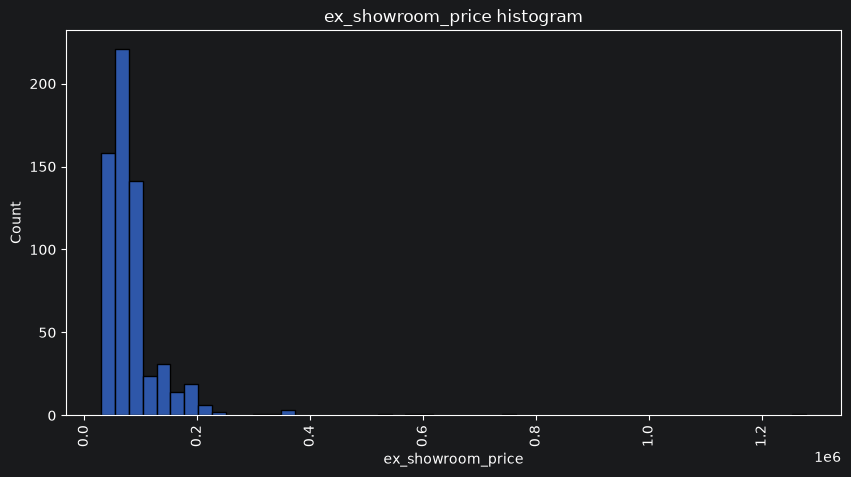

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(axis="x", rotation=90)
plt.title(f"ex_showroom_price histogram")
sns.histplot(data=data, x=data.ex_showroom_price, ax=ax)
plt.show()

# "selling_price" VS "year"

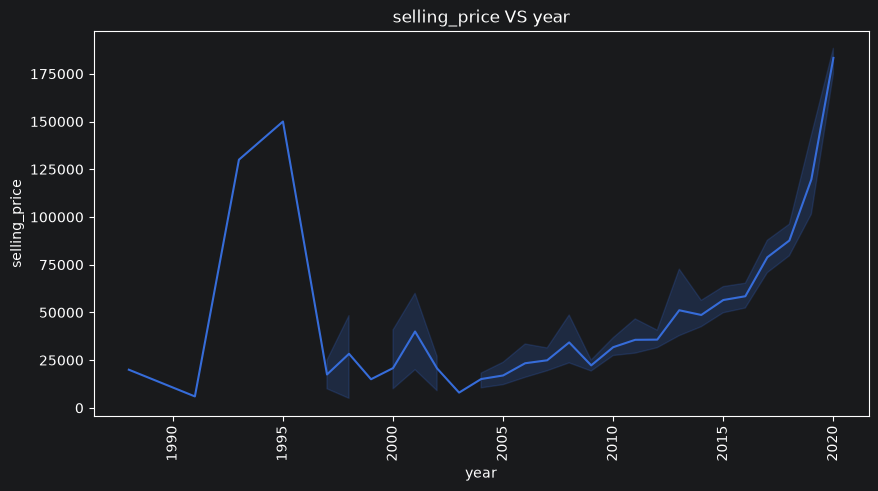

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(axis="x", rotation=90)
plt.title("selling_price VS year")
sns.lineplot(data=data, y=data.selling_price, x=data.year)
plt.show()

# "selling_price" VS "seller_type"

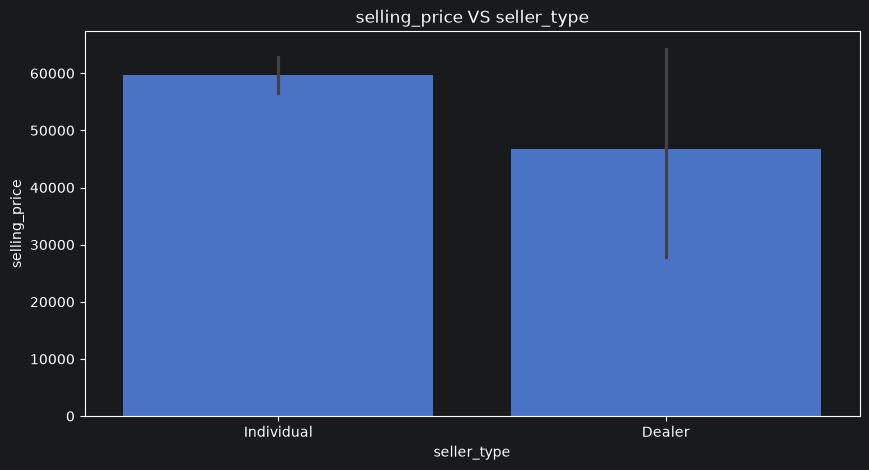

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.title("selling_price VS seller_type")
sns.barplot(data=data, y=data.selling_price, x=data.seller_type)
plt.show()